Verify that the data of your personal project have at least 2 continuous and 2 categorical or discrete variables. 
Otherwise change data.
With your data, proceed to the three analyses you did during the tutorial 1.

Understand data as actual values of random variables; Choose 2 variables of your project and make a probability model of them by assuming that each observation has been obtained by a simple random sampling (i.e. by drawing units uniformly with replacement in the population). Display a frequency table for your variables. Give explicitly the random variables involved and their expression in terms of your sample. What is the joint distribution of the frequencies displayed in the table ? 

The size of the sample, the number of classes and the notations must be clear. 
Proceed to a simple regression with 2 CONTINUOUS variables of your dataset. In this first part, you will write the model with all the assumptions (theoretical results must be written as a markdown), continue with the estimation of parameters, the regression line with all the necessary plots, CI for the prediction and the mean prediction. Outliers and residual analysis must be included. Make a decision about outliers (keep them or erase them from the set). 

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [47]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [49]:
#sns.pairplot(df.sample(n=300))

In [50]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [51]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=1000) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Three Dog Night,On air 70's Hits,An Old Fashioned Love Song - Single Version,0.5550,-10.615,0.50800,10,country
1,Péricles,Pagode do Pericão (Ao Vivo),Vai Babar / Poder de Sedução - Ao Vivo,0.8130,-5.895,0.71700,7,pagode
2,Oliverse,Dimension EP,Get High,0.9790,-1.476,0.00113,5,dub
3,Maria Bethânia,Era Pra Ser - Single,Era Pra Ser,0.0716,-11.029,0.82100,7,samba
4,Igão;Kyan;Nagalli;Bvga;Toledo,Chave do Cofre,Chave do Cofre,0.6950,-5.646,0.44100,9,funk
...,...,...,...,...,...,...,...,...
995,Arc North;Cour;Charlie Miller,Youngblood,Youngblood,0.8910,-2.239,0.01920,7,edm
996,Kid Loco,Confessions of a Belladonna Eater & Remixes,The Morning After,0.5920,-7.961,0.22400,11,electronic
997,Jimmy Sabater,"Amorometro, Vol. 1: Boleros Antillanos",Salchicha Con Huevo,0.4070,-15.751,0.76900,5,salsa
998,Christopher Titus,Neverlution!,Terrorism Is Over,0.6250,-10.971,0.91500,2,comedy


/Users/enzoducros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


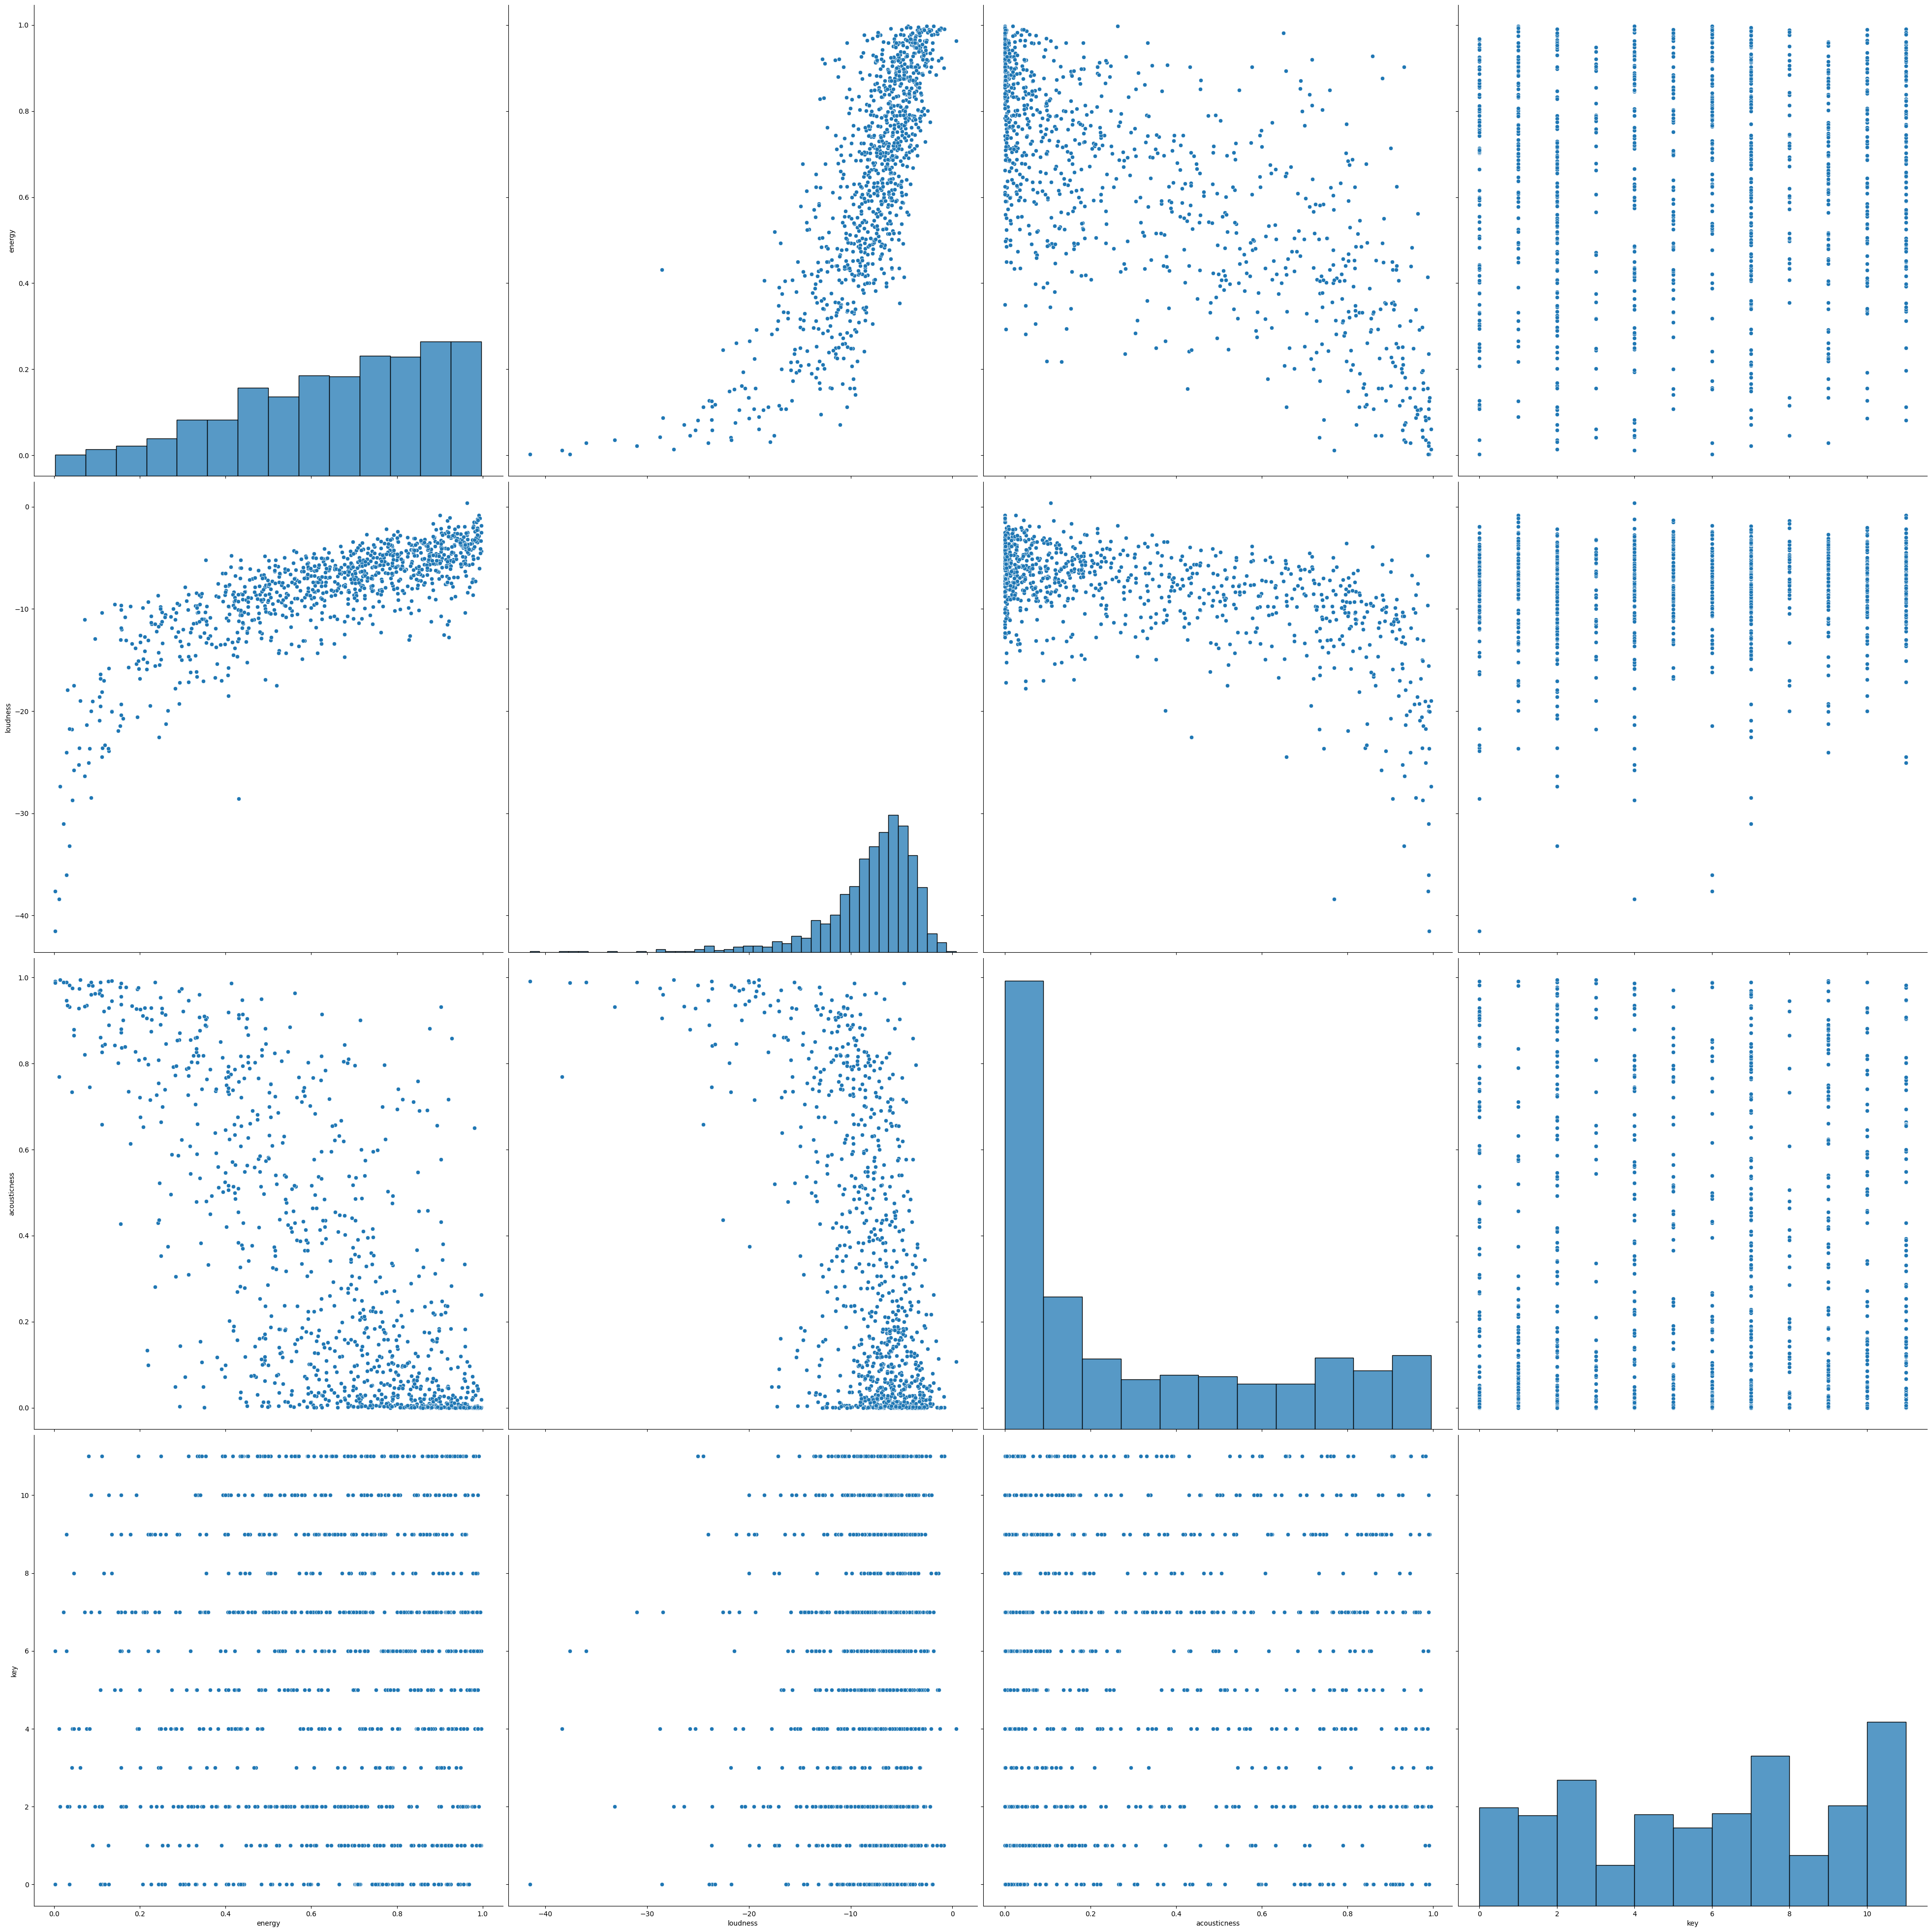

In [52]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

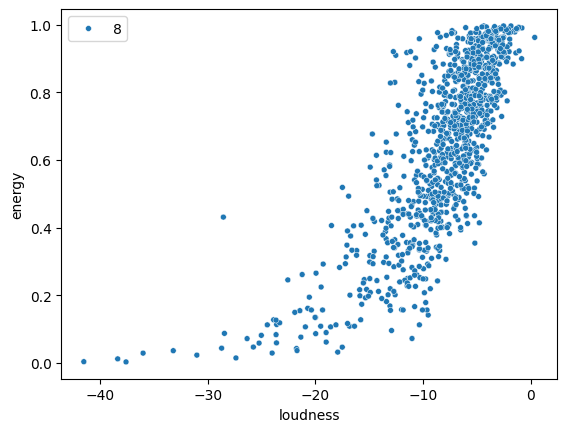

In [53]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

In [54]:
np.corrcoef(x=spotify_lr.loudness,y=spotify_lr.energy)

array([[1.        , 0.77261117],
       [0.77261117, 1.        ]])

# STOP HERE AND PASS ON BECAUSE LINEARIZATION KILLS THE CORR

**1. Linearisation**

In [ ]:
'''# to linearise , we'll apply a map to the y value
spotify_lr["energy"] = spotify_lr["energy"].map(np.log)
spotify_lr
'''

/var/folders/xl/0wxp8zgx2wz1_sw2nyhksnr00000gn/T/ipykernel_56333/1081503018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_lr["energy"] = spotify_lr["energy"].map(np.log)


,loudness,energy
0,-8.608,-0.926341
1,-8.080,-0.298406
2,-7.283,-0.663588
3,-6.024,-0.711311
4,-4.455,-0.397497
...,...,...
995,-4.669,-0.218156
996,-11.912,-1.248273
997,-3.882,-0.019183
998,-5.695,-0.244623


In [ ]:
'''spotify_lr = spotify_lr.where(spotify_lr > -10)
spotify_lr = spotify_lr.dropna()
spotify_lr'''

,loudness,energy
0,-8.608,-0.926341
1,-8.080,-0.298406
2,-7.283,-0.663588
3,-6.024,-0.711311
4,-4.455,-0.397497
...,...,...
994,-3.450,-0.130109
995,-4.669,-0.218156
997,-3.882,-0.019183
998,-5.695,-0.244623


array([[1.        , 0.59168928],
       [0.59168928, 1.        ]])

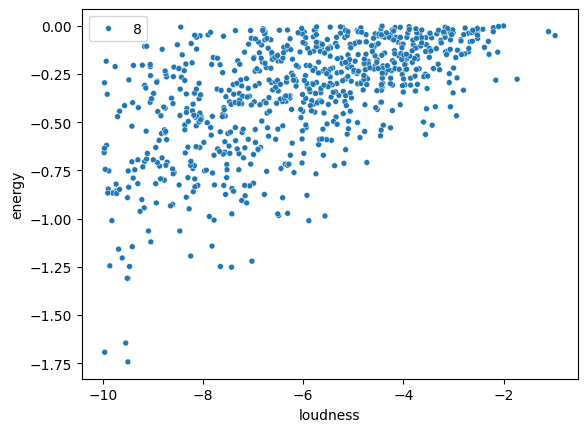

In [ ]:
'''sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_lr.energy,spotify_lr.loudness)
# hey , the corr coefficient is 0.8 , it's good 
'''

# CONTINUE HERE

**2. Start of Linear Regression**

In [55]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]
lr

LinregressResult(slope=np.float64(0.03864344960212746), intercept=np.float64(0.9574282737346347), rvalue=np.float64(0.7726111661286066), pvalue=np.float64(3.9804963240996516e-199), stderr=np.float64(0.0010051733004857889), intercept_stderr=np.float64(0.009609933948344607))

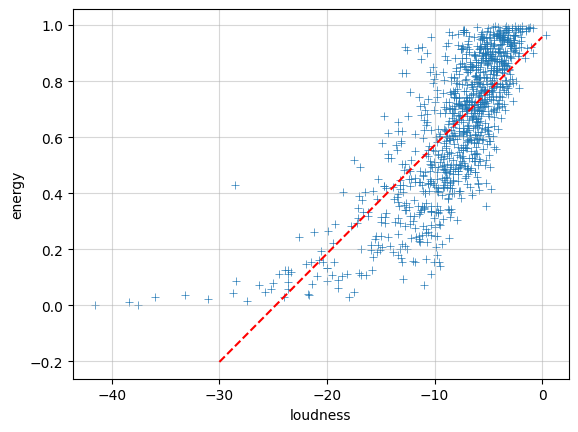

In [56]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)


### continum analysis

In [66]:
x = spotify_lr.loudness
y = spotify_lr.energy
n = len(spotify_lr.loudness)

hy = a+b*x
e = y - hy

sse = np.sum(e**2)
hs2 = sse/(n-2)

residual analysis

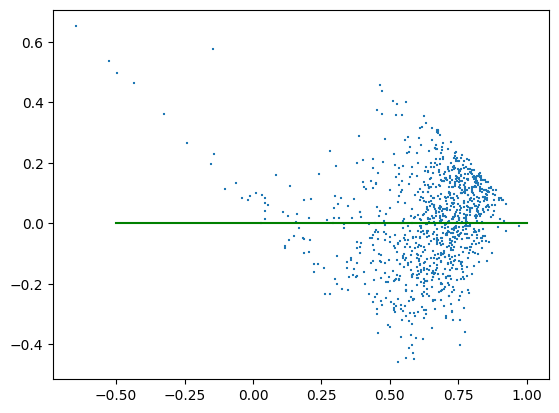

In [58]:
plt.scatter(x=hy,y=e,marker="+",s= 4)
plt.plot([-0.5,1],[0,0],'g')

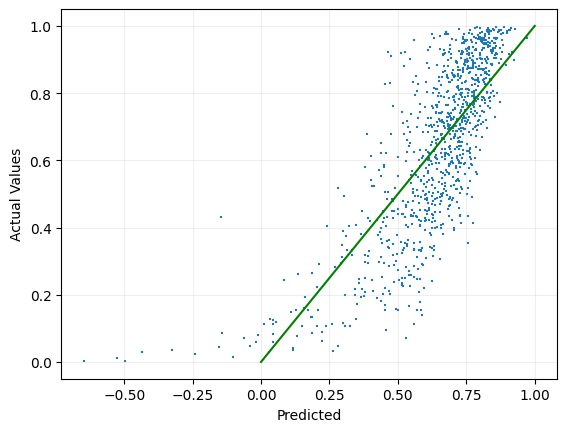

In [64]:
plt.scatter(x=hy,y=y,marker="+",s=7-5)
plt.plot([0,1],[0,1],'g')
plt.xlabel('Predicted')
plt.ylabel('Actual Values')
plt.grid(visible=True,alpha=0.2)

### q-q plot

In [68]:
dist = st.norm(loc=0,scale=np.sqrt(hs2))

Text(0.5, 1.0, 'q-q plot')

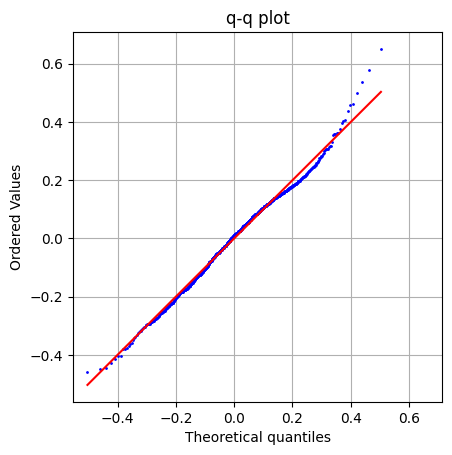

In [72]:
st.probplot(e,dist=dist,plot=plt)
plt.gca().lines[0].set_markersize(1)
plt.axis('square')
plt.grid()
plt.title("q-q plot")

**INterpratation** : the q-q plot is fine , however the residuals express heteroscadisticity , maybe they just have different sigmas. So technically we cannot apply our linear regression

# Anova regression

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [12]:
spotify



,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Keith Urban,Ripcord,Blue Ain't Your Color,0.4160,-7.865,0.6170,7,country
1,Thiago Ramalho,Ganhar o Mundo,Ganhar o Mundo,0.3680,-10.887,0.0764,4,gospel
2,Wolfgang Amadeus Mozart;Academy of St. Martin ...,Mozart - A Classical Dawn,"Symphony No. 25 in G minor, K.183: 1. Allegro ...",0.1280,-17.219,0.9830,7,classical
3,Alphaxone,The Infinite Void,Center X,0.2360,-27.826,0.1690,3,iranian
4,Fäaschtbänkler,Flamingo + Hoch die Hände Wochenende,Nur für dich,0.5550,-7.281,0.0462,10,party
...,...,...,...,...,...,...,...,...
995,Jim Brickman,"Soothe, Vol. 2: Sleep (Music for Tranquil Slum...",Slumber Deep,0.0303,-22.357,0.9540,5,new-age
996,Smash Mouth,OO's Music Grandi Successi,All Star,0.8670,-5.881,0.0394,11,alternative
997,Libor Kolman,Quand vous souriez,Quand vous souriez,0.0590,-25.084,0.9960,1,piano
998,Billie Eilish,Halloween Party 2022,you should see me in a crown,0.5340,-10.348,0.5190,4,pop


In [13]:
types_list = ['house','r-n-b','jazz','brazil','emo','acoustic','latino','drum-and-bass','opera']
spotify_Anova = spotify[spotify['track_genre'].isin(types_list)]
spotify_Anova

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
18,Fall Out Boy,Emo Christmas 2022,Yule Shoot Your Eye Out,0.522,-7.420,0.6960,4,emo
28,O Rappa,Acústico MTV,Reza vela - Ao vivo acústico,0.780,-7.953,0.3360,1,r-n-b
32,Daddy Yankee,Perreo en Halloween,RUMBATÓN,0.909,-4.034,0.0471,3,latino
34,Padre Marcelo Rossi,Ágape Musical,Meu Mestre,0.451,-9.247,0.6860,4,brazil
37,Dean Martin,Classic Christmas 2022,Luna Mezzo Mare - 2001 Remastered,0.283,-8.335,0.7980,2,jazz
...,...,...,...,...,...,...,...,...
956,Dean Martin,pov: you have a holly jolly christmas,Let It Snow! Let It Snow! Let It Snow!,0.332,-10.312,0.7870,1,jazz
965,Patrizio,"Papà..è Natale, vol. 1",O minorenne,0.567,-6.895,0.0605,0,opera
966,Sigma;Louis III,Anywhere,Anywhere,0.872,-3.279,0.0162,11,drum-and-bass
978,Luny Tunes;Don Omar;Sharlene;Maluma,Carrete con besties,La Fila,0.931,-1.483,0.1110,1,latino


In [14]:
spotify_Anova = spotify_Anova[['track_genre','energy']]
spotify_Anova

,track_genre,energy
18,emo,0.522
28,r-n-b,0.780
32,latino,0.909
34,brazil,0.451
37,jazz,0.283
...,...,...
956,jazz,0.332
965,opera,0.567
966,drum-and-bass,0.872
978,latino,0.931


<Axes: xlabel='track_genre', ylabel='energy'>

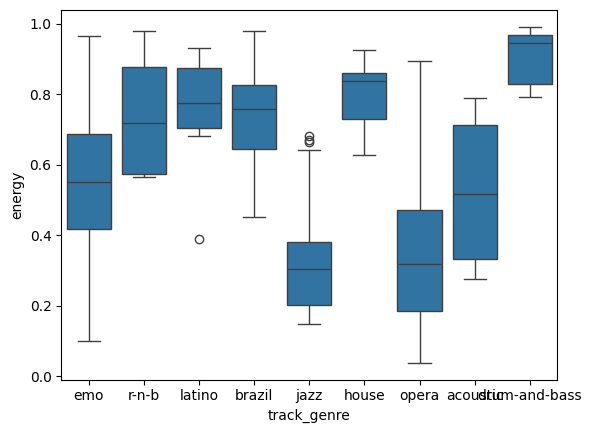

In [ ]:
# BOxplottts 
sns.boxplot(data=spotify_Anova, x='track_genre', y='energy')

Hey , there seems to be a good difference in between types  , and also some that maybe are very similar ( for example drum&Bass and house that are very similar in style so it's not suprising that they have similar boxplots )

## analysis of variance

In [19]:
spotify_Anova.groupby('track_genre').describe()

energy                                                       \
               count      mean       std     min      25%    50%      75%   
track_genre                                                                 
acoustic        10.0  0.526800  0.201771  0.2750  0.33425  0.518  0.71200   
brazil          10.0  0.742400  0.168748  0.4510  0.64425  0.760  0.82800   
drum-and-bass    9.0  0.902222  0.077730  0.7930  0.82900  0.946  0.96800   
emo             12.0  0.562667  0.250354  0.1000  0.41850  0.551  0.68650   
house            9.0  0.800889  0.103508  0.6270  0.72900  0.837  0.86000   
jazz            17.0  0.355294  0.191056  0.1480  0.20100  0.304  0.38200   
latino           6.0  0.744000  0.196377  0.3910  0.70475  0.776  0.87575   
opera           10.0  0.353110  0.258282  0.0384  0.18625  0.320  0.47100   
r-n-b            8.0  0.741125  0.173089  0.5660  0.57300  0.718  0.87750   

                      
                 max  
track_genre           
acoustic       0.791  
brazil         0.980  
drum-and-bass  0.992  
emo            0.965  
house          0.927  
jazz           0.681  
latino         0.931  
opera          0.895  
r-n-b          0.981

In [38]:
groups = [g["energy"].to_numpy()for _, g in spotify_Anova.groupby("track_genre")]

anova = st.f_oneway(groups[0],groups[1],groups[2],groups[3],groups[4],groups[5],groups[6],groups[7],groups[8])
print(f"the d statistic is {anova.statistic} with p-value {anova.pvalue}")
print(f" the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O")

the d statistic is 11.386320387854285 with p-value 1.0255618447420198e-10
 the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O
